# WaveNet peak-location training

This notebook presents a complete, reproducible DeepPeak workflow:

1. generate noisy multi-peak traces;
2. inspect the dataset and its clean targets;
3. split the data reproducibly;
4. train a WaveNet detector;
5. evaluate it with `ModelEvaluationResult`; and
6. inspect predictions with the shared scientific plotting helper.

The notebook uses the current `DeepPeak.generation` and `DeepPeak.models` APIs.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import sys

# Make the notebook work when launched from the repository root, the
# package directory, or the notebook directory.
HERE = Path.cwd().resolve()
SEARCH_PATHS = (HERE, *HERE.parents)
PROJECT_ROOT = next(
    path for path in SEARCH_PATHS
    if (path / "pyproject.toml").exists() and (path / "DeepPeak").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from MPSPlots.styles import scientific

from DeepPeak import Gaussian, SignalGenerator, UniformCount
from DeepPeak.models import (
    TrainingConfig,
    WaveNet,
    plot_predictions,
    smooth_bce
)

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
plt.style.use(scientific)

## 2. Generate a realistic training dataset

Each trace contains one to four Gaussian pulses. The generator retains both
the noisy observation and the clean signal, while `labels` marks the true
pulse locations.

In [2]:
SEQUENCE_LENGTH = 256
N_SAMPLES = 512 * 8

generator = SignalGenerator(sequence_length=SEQUENCE_LENGTH)
kernel = Gaussian(
    amplitude=(0.8, 2.5),
    position=(20.0, SEQUENCE_LENGTH - 20.0),
    width=(4.0, 12.0),
)

dataset = generator.generate(
    n_samples=N_SAMPLES,
    kernel=kernel,
    peak_count=UniformCount(bounds=(1, 3)),
    noise_std=(0.02, 0.10),
    noise_profile="linear",
    noise_end_scale=(1.0, 2.0),
    baseline_level=(0.0, 0.05),
    seed=SEED,
)

print("project root:", PROJECT_ROOT)
print(dataset)
print("signals:", dataset.signals.shape)
print("labels:", dataset.labels.shape)

project root: /Users/m.poinsinetdesivry-houle/Desktop/GitRepositories/DeepPeak
DataSet(signals, clean_signals, amplitudes, positions, widths, rise_scales, decay_scales, labels, x_values, num_peaks, baseline_level, instrument_response, saturation, quantization_step, peak_presence, active_num_peaks, n_samples, sequence_length)
signals: (4096, 256)
labels: (4096, 256)


In [5]:
targets = dataset.targets(
    target="reference",
    width=1.0,
    width_definition="sigma",
)

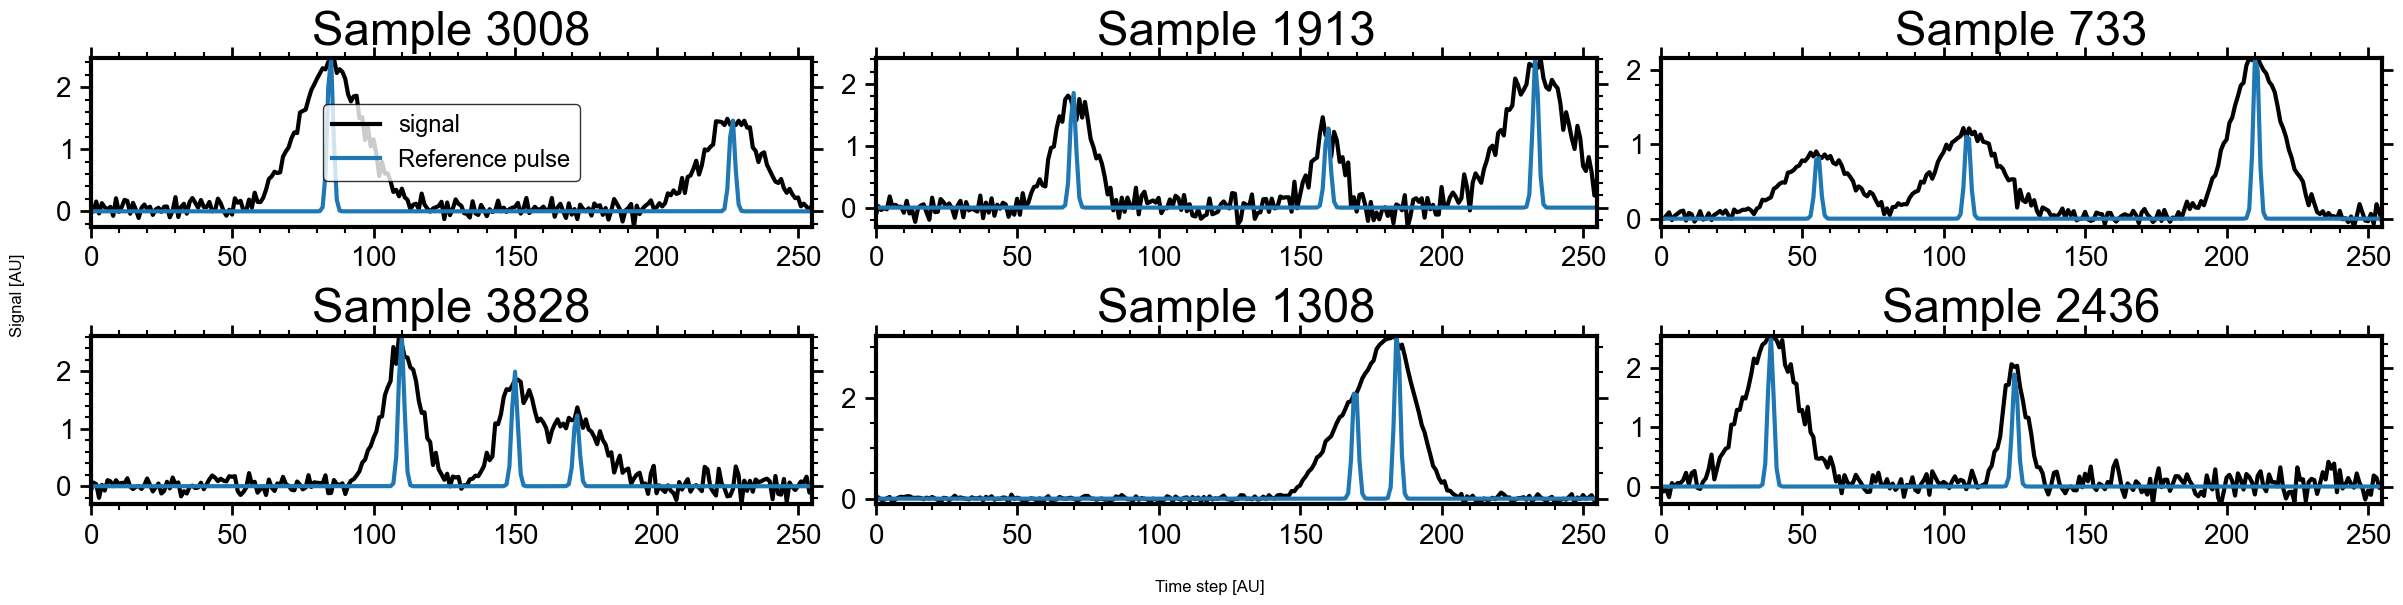

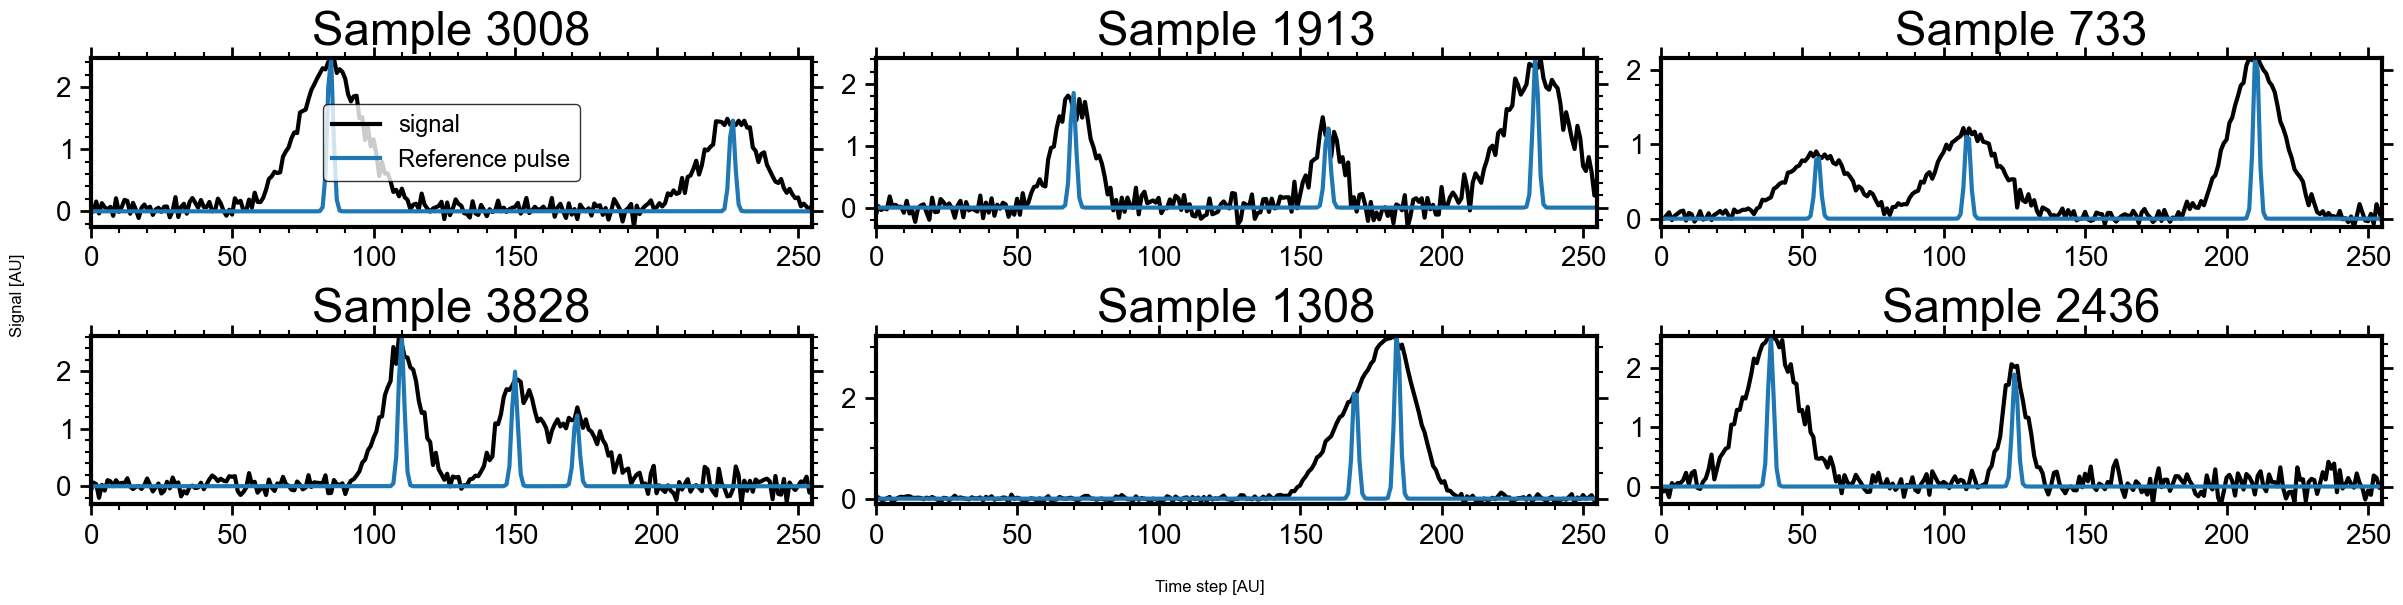

In [4]:
dataset.plot(
    number_of_samples=6,
    number_of_columns=3,
    randomize_signal=True,
    reference_pulse_trace=targets,
)

## 3. Prepare deterministic train and test sets

The dataset now owns the input/target shape convention. Neural inputs are
returned as `(batch, time, channel)` arrays, and `targets()` selects the
pulse labels explicitly.

In [6]:
train, test = dataset.train_test_split(test_size=0.2, seed=SEED)

train_inputs = train.to_model_inputs(normalization="zscore")
train_targets = train.targets(
    target="reference",
    width=1.0,
    width_definition="sigma",
)

test_inputs = test.to_model_inputs(normalization="zscore")
test_targets = test.targets(
    target="reference",
    width=1.0,
    width_definition="sigma",
)

print("train inputs/targets:", train_inputs.shape, train_targets.shape)
print("test inputs/targets: ", test_inputs.shape, test_targets.shape)

train inputs/targets: (3276, 256, 1) (3276, 256, 1)
test inputs/targets:  (820, 256, 1) (820, 256, 1)


## 4. Build and train WaveNet

The model predicts a probability at every time sample. The training helper
uses the dataset directly, avoiding duplicated preprocessing code.

In [7]:
from DeepPeak.models import ShapeAwarePulseLoss

model = WaveNet(
    sequence_length=SEQUENCE_LENGTH,
    num_filters=32,
    num_dilation_layers=6,
    kernel_size=4,
    output_activation="linear",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=ShapeAwarePulseLoss(
        amplitude_weight=1.0,
        shape_weight=0.25,
        smoothness_weight=0.05,
    ),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)


model.build()
model.summary()

Model: "WaveNetDeconvolver"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 256, 32)   │         64 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_0      │ (None, 256, 32)   │      4,128 │ input_projection… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0 (Conv1D)      │ (None, 256, 32)   │      1,056 │ dilated_conv_0[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_0      │ (None, 256, 32)   │          0 │ input_projection… │
│ (Add)               │                   │            │ res_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_1      │ (None, 256, 32)   │      4,128 │ residual_add_0[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_1 (Conv1D)      │ (None, 256, 32)   │      1,056 │ dilated_conv_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_1      │ (None, 256, 32)   │          0 │ residual_add_0[0… │
│ (Add)               │                   │            │ res_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_2      │ (None, 256, 32)   │      4,128 │ residual_add_1[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2 (Conv1D)      │ (None, 256, 32)   │      1,056 │ dilated_conv_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_2      │ (None, 256, 32)   │          0 │ residual_add_1[0… │
│ (Add)               │                   │            │ res_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_3      │ (None, 256, 32)   │      4,128 │ residual_add_2[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_3 (Conv1D)      │ (None, 256, 32)   │      1,056 │ dilated_conv_3[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_3      │ (None, 256, 32)   │          0 │ residual_add_2[0… │
│ (Add)               │                   │            │ res_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_4      │ (None, 256, 32)   │      4,128 │ residual_add_3[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_4 (Conv1D)      │ (None, 256, 32)   │      1,056 │ dilated_conv_4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_4      │ (None, 256, 32)   │          0 │ residual_add_3[0… │
│ (Add)               │                   │            │ res_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_5      │ (None, 256, 32)   │      4,128 │ residual_add_4[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_0 (Conv1D)     │ (None, 256, 32)   │      1,056 │ dilated_conv_0[0

 Total params: 36,481 (142.50 KB)

 Trainable params: 36,481 (142.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
train_targets = train.targets(
    target="reference",
    width=1.0,
    width_definition="sigma",
)

history = model.fit_dataset(
    train,
    target=train_targets,
    normalization="zscore",
    config=TrainingConfig(
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        patience=3,
        monitor="val_mae",
        seed=SEED,
    ),
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0090 - mae: 0.0255 - val_loss: 0.0106 - val_mae: 0.0254 - learning_rate: 5.0000e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0089 - mae: 0.0253 - val_loss: 0.0106 - val_mae: 0.0253 - learning_rate: 5.0000e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0089 - mae: 0.0252 - val_loss: 0.0105 - val_mae: 0.0252 - learning_rate: 5.0000e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0088 - mae: 0.0251 - val_loss: 0.0104 - val_mae: 0.0250 - learning_rate: 5.0000e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0088 - mae: 0.0250 - val_loss: 0.0104 - val_mae: 0.0250 - learning_rate: 5.0000e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0087 - mae: 0.0248 - val_loss: 0.0104 - val_mae: 0.0249 - learning_rate: 5.0000e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0087 - mae: 0.0247 - val_loss: 0.0103 - val_mae: 0.0245 - learning_ra

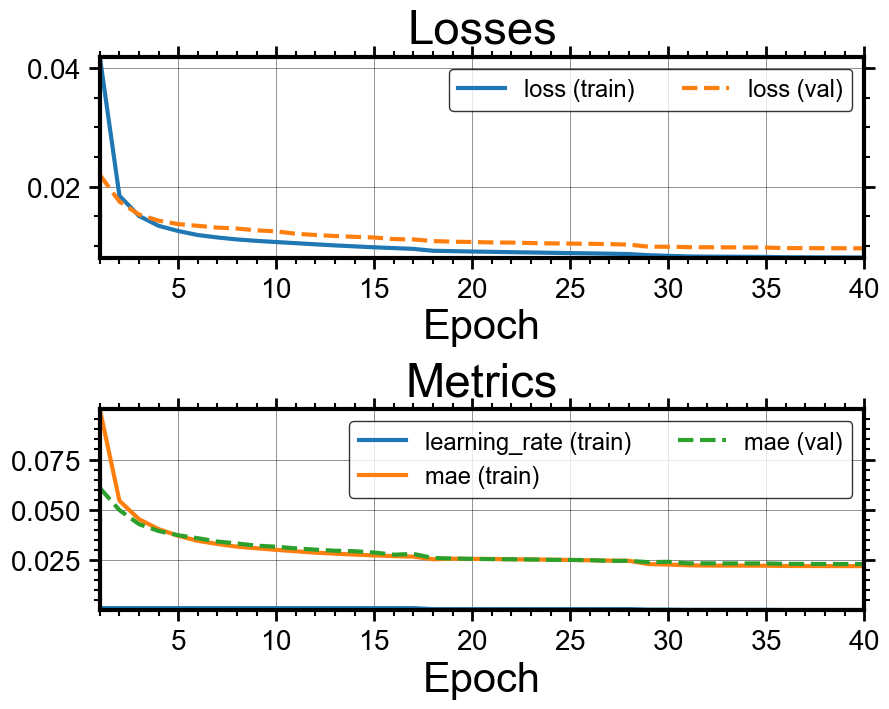

In [13]:
_ = model.plot_model_history()

## 5. Evaluate detection quality

`evaluate_dataset` returns a `ModelEvaluationResult`, which keeps the
metrics together with predictions and targets for later analysis. We
complement the Keras metrics with thresholded detection metrics and a
simple localization summary.

In [14]:
evaluation = model.evaluate_dataset(
    test,
    target="labels",
    normalization="zscore",
    batch_size=32,
)

print("Keras metrics:", evaluation.summary())

target_values = evaluation.targets[..., 0]
prediction_values = evaluation.predictions[..., 0]
threshold = 0.5
target_binary = target_values >= 0.5
prediction_binary = prediction_values >= threshold

true_positive = np.count_nonzero(target_binary & prediction_binary)
false_positive = np.count_nonzero(~target_binary & prediction_binary)
false_negative = np.count_nonzero(target_binary & ~prediction_binary)
precision = true_positive / max(true_positive + false_positive, 1)
recall = true_positive / max(true_positive + false_negative, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-12)
iou = true_positive / max(true_positive + false_positive + false_negative, 1)

print({
    "threshold": threshold,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "iou": iou,
})

Keras metrics: {'loss': 0.024304112419486046, 'mae': 0.0356815904378891}
{'threshold': 0.5, 'precision': 0.2954075299958626, 'recall': 0.8592057761732852, 'f1': 0.4396551724137931, 'iou': 0.281767955801105}


mean absolute residual: 0.035681590276414966


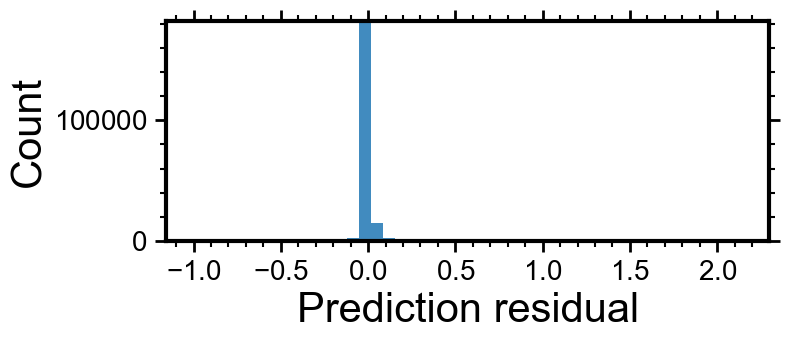

In [15]:
residuals = evaluation.residuals[..., 0]
print("mean absolute residual:", np.mean(np.abs(residuals)))

with plt.style.context(scientific):
    figure, axis = plt.subplots(figsize=(8, 3.5))
    axis.hist(residuals.ravel(), bins=50, color="C0", alpha=0.85)
    axis.set(xlabel="Prediction residual", ylabel="Count")
    figure.tight_layout()
    _ = plt.show()

### Approximate peak localization

For each trace, predicted and true peak indices are matched greedily
within a small sample tolerance. This is useful for understanding
localization behavior beyond pointwise pixel metrics.

In [16]:
def localization_scores(targets, predictions, tolerance=3):
    matched = 0
    true_count = 0
    predicted_count = 0
    errors = []
    for true_trace, predicted_trace in zip(targets, predictions):
        true_indices = np.flatnonzero(true_trace >= 0.5)
        predicted_indices = np.flatnonzero(predicted_trace >= threshold)
        true_count += true_indices.size
        predicted_count += predicted_indices.size
        available = list(true_indices)
        for predicted_index in predicted_indices:
            if not available:
                continue
            distances = np.abs(np.asarray(available) - predicted_index)
            nearest = int(np.argmin(distances))
            if distances[nearest] <= tolerance:
                matched += 1
                errors.append(float(distances[nearest]))
                available.pop(nearest)
    return {
        "matched_peaks": matched,
        "localization_precision": matched / max(predicted_count, 1),
        "localization_recall": matched / max(true_count, 1),
        "mean_error_samples": np.mean(errors) if errors else np.nan,
    }

localization_scores(target_values, prediction_values)

{'matched_peaks': 1541,
 'localization_precision': 0.3187836160529582,
 'localization_recall': 0.9271961492178099,
 'mean_error_samples': np.float64(1.2225827384815056)}

## 6. Visualize predictions

The shared plotting helper handles channel dimensions, sample selection,
the scientific style, and one figure-level legend automatically.

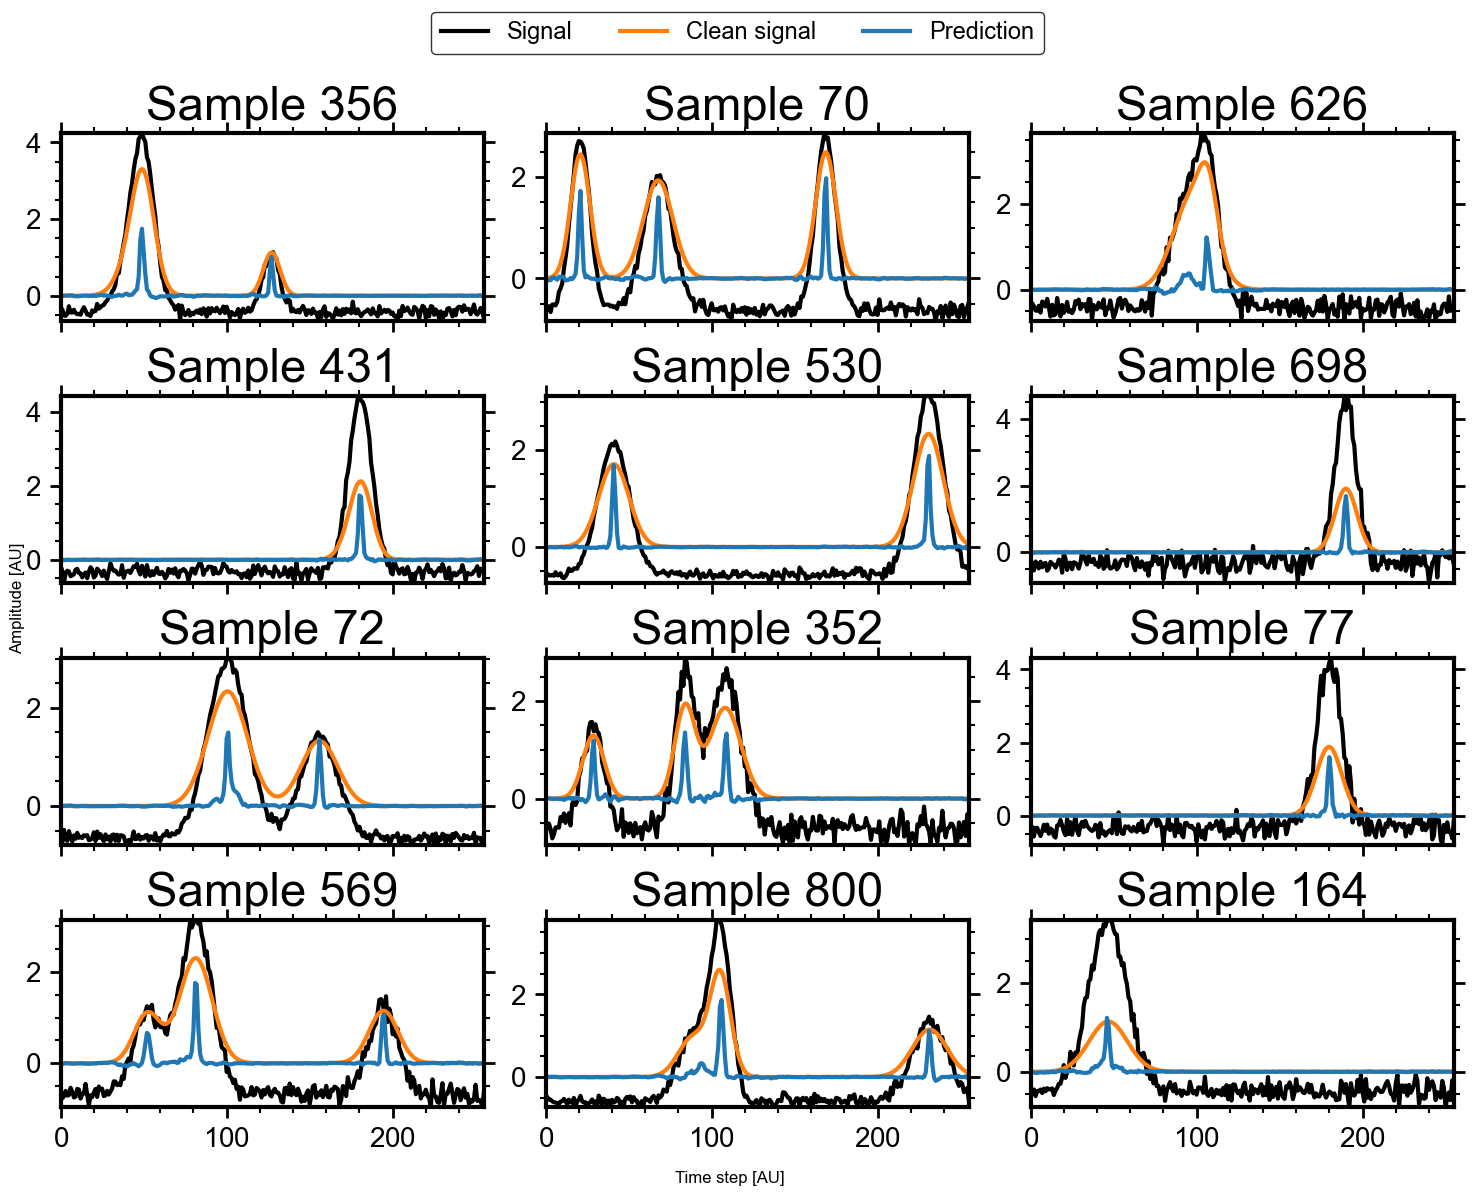

In [17]:
_ = plot_predictions(
    model,
    test,
    n_samples=12,
    n_columns=3,
    normalization="zscore",
    randomize=True,
    seed=SEED,
)

## Takeaways

- `SignalGenerator` produces reproducible synthetic training data.
- `DataSet` centralizes validation, normalization, targets, and splitting.
- `fit_dataset` and `evaluate_dataset` keep training/evaluation consistent.
- `ModelEvaluationResult` makes metrics and residual analysis reusable.
- `plot_predictions` provides a compact visual check of model behavior.